<a href="https://colab.research.google.com/github/Thashmikab/london-smart-meter-analysis/blob/main/notebooks/05_peak_and_carbon_tariff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 · A tariff that targets the evening peak and carbon together

Notebook 04 found that the trial's price events weren't aligned with grid carbon, so they couldn't cut emissions through timing. This notebook asks what the **same household response** would have achieved if the events had been placed differently: by carbon alone, or by a design that targets the evening peak *and* carbon. It then checks whether the design still works when the events have to be chosen a day ahead from a forecast, as a real tariff would.

**The answers, in plain terms**

- **Households responded more strongly to events than first measured.** During High-price events, time-of-use households cut their use by about **8%**; during Low-price periods they used about **6% more**. A placebo check on 2012, before anyone saw a price, showed the naive estimate understated the response.
- **The trial's actual event timing slightly increased emissions** (about +2.6 kg CO₂ per household a year from the event responses), because Low-price periods fell at slightly dirtier times.
- **A combined design does best on every measure.** Put High events in the evening (15:00–21:00) on the grid's dirtiest days, and Low events in the cleanest hours outside the evening. With the same number of events and the same response, it cuts the evening peak **about ten times more** than the actual schedule and turns the carbon effect into a saving: **about 6.7 kg CO₂ less per household a year** than the actual schedule, or roughly **22,000 tonnes a year** if every London home were on it.
- **Chasing carbon alone backfires on the network.** Aligning events with marginal carbon puts Low prices in the early evening and *raises* the evening peak.
- **It works with a day-ahead forecast.** Choosing the days from a simple "same as yesterday" rule keeps about **94%** of the perfect-knowledge saving. A machine-learning model was no more accurate than that rule, because what matters is ranking which days are dirtiest, and carbon intensity changes slowly from one day to the next.
- **The scale is small.** 6.7 kg is about 0.4% of a household's electricity emissions. Event pricing is a modest lever; the finding is about direction: a badly timed tariff can quietly add carbon, a well-designed one cuts the peak and carbon together.

**Inputs:** `halfhourly_cleaned`, `households`, `tariffs_2013`, `generation_mix`, `weather_hourly` and `bank_holidays` from notebooks 01 and 02.

## Setup

In [1]:
!pip install pyspark

In [2]:
import numpy as np
import pandas as pd
from google.colab import drive
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col

In [3]:
#@title Start Spark and load the tables

spark = SparkSession.builder.appName("london-smart-meters-carbon-tariff").getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "UTC")

drive.mount("/content/drive")
DRIVE = "/content/drive/MyDrive/london-smart-meters"

# The half-hourly readings are big: copy them to local disk first, as in notebook 02
!mkdir -p data/parquet
!cp -r {DRIVE}/halfhourly_cleaned data/parquet/

hh = spark.read.parquet("data/parquet/halfhourly_cleaned")
households = spark.read.parquet(f"{DRIVE}/households").filter("in_2013_analysis").select("household_id", "tariff")
tariffs = spark.read.parquet(f"{DRIVE}/tariffs_2013")
genMix_df = spark.read.parquet(f"{DRIVE}/generation_mix")

Mounted at /content/drive


## 1. One table of half-hours

For every half-hour of 2012 and 2013: the average consumption of a standard household and of a time-of-use household, the grid's carbon intensity, and the price band (2013). Each reading is assigned to the half-hour it covers (the end-of-interval convention from notebook 02).

**Placebo column.** Each 2012 half-hour also gets the band that the same weekday and time had 52 weeks later. Nobody faced prices in 2012, so this shows whether the event *times* were unusual in themselves.

Result: 17,568 half-hours in 2012 and 17,520 in 2013. The table is saved to Drive so later sessions can skip this step.

In [4]:
#@title Average consumption per household in every half-hour of 2012 and 2013

profile = (hh.filter(~col("zero_day"))
    # end-of-interval convention: a reading covers the half-hour starting 30 minutes earlier
    .withColumn("interval_start", col("timestamp") - F.expr("INTERVAL 30 MINUTES"))
    .filter(F.year("interval_start").isin(2012, 2013))
    .join(F.broadcast(households), "household_id")
    .groupBy("interval_start").pivot("tariff", ["Std", "ToU"]).agg(F.avg("energy_kwh"))
    .join(genMix_df.select(col("DATETIME").alias("interval_start"),
                           col("CARBON_INTENSITY").alias("ci")), "interval_start")
    .toPandas()
    .sort_values("interval_start")
    .reset_index(drop=True))

# Price band for each 2013 half-hour
bands = tariffs.select(col("TariffDateTime").alias("interval_start"), col("Tariff").alias("band")).toPandas()
profile = profile.merge(bands, on="interval_start", how="left")

# Placebo: give each 2012 half-hour the band of the same weekday and time 52 weeks later
placebo = bands.assign(interval_start=bands["interval_start"] - pd.Timedelta(days=364)).rename(columns={"band": "band_placebo"})
profile = profile.merge(placebo, on="interval_start", how="left")

profile["year"] = profile["interval_start"].dt.year
print(profile.shape)
print(profile.groupby("year").size())       # about 17,500 half-hours per year
profile.head()

profile.to_csv(f"{DRIVE}/halfhour_profile_2012_2013.csv", index=False)   # so later sessions can skip this step

(35088, 7)
year
2012    17568
2013    17520
dtype: int64


## 2. How strongly did households respond to each price band?

For each band: the time-of-use household's use divided by the standard household's, relative to Normal.

| Band | 2013 (real prices) | 2012 placebo (same times, no prices) | **Response** |
|---|---:|---:|---:|
| High | −4.7% | +3.5% | **−7.9%** |
| Low | +5.5% | −0.5% | **+6.0%** |

At the times that would become High events, time-of-use households already used 3.5% more than usual in 2012, so the naive 2013 figure understates the response. Dividing the 2013 ratio by the 2012 ratio gives the response used from here on: **about 8% less use in High-price events, about 6% more in Low-price periods.** Fewer time-of-use households were in the trial in early 2012, so the placebo rests on a somewhat different mix of households; the direction of the correction is clear, its exact size approximate.

In [5]:
#@title How did ToU households respond to each price band?

def response_table(df, band_col):
    t = df.groupby(band_col)[["Std", "ToU"]].mean()
    t["ToU_vs_Std"] = t["ToU"] / t["Std"]
    t["response_vs_Normal_%"] = 100 * (t["ToU_vs_Std"] / t.loc["Normal", "ToU_vs_Std"] - 1)
    return t.round(4)

print("2013, real prices")
print(response_table(profile[profile.year == 2013], "band"))

print("\n2012, same times a year earlier (no prices yet) - placebo")
print(response_table(profile[profile.year == 2012], "band_placebo"))

2013, real prices
           Std     ToU  ToU_vs_Std  response_vs_Normal_%
band                                                    
High    0.2578  0.2244      0.8702               -4.6633
Low     0.2181  0.2100      0.9629                5.4932
Normal  0.2129  0.1943      0.9128                0.0000

2012, same times a year earlier (no prices yet) - placebo
                 Std     ToU  ToU_vs_Std  response_vs_Normal_%
band_placebo                                                  
High          0.2575  0.2499      0.9703                3.5104
Low           0.2228  0.2078      0.9325               -0.5227
Normal        0.2174  0.2038      0.9374                0.0000


## 3. Re-time the events (perfect knowledge of 2013)

Four schedules, each with the trial's number of events as three-hour blocks (131 High, 277 Low, matching 788 and 1,660 half-hours):

| Schedule | High events | Low events |
|---|---|---|
| Actual 2013 | as the trial ran | as the trial ran |
| Carbon-aligned (average) | blocks with the dirtiest grid mix | the cleanest blocks |
| Carbon-aligned (marginal) | blocks where extra demand is dirtiest at the margin | the cleanest at the margin |
| Peak + carbon combined | evening blocks (15:00–21:00) on the dirtiest days | the cleanest blocks outside the evening |

**How each is scored.** A time-of-use household's use without price signals is the standard household's use scaled to the time-of-use group's Normal level. Each schedule changes it by the measured response in its event half-hours (−7.9% High, +6.0% Low). The changes are added up for the year: total use, evening-peak use (16:00–19:00), and CO₂ by average and by marginal intensity (marginal by hour of day, as in notebook 04). Negative means less.

| Schedule | kWh | Evening-peak kWh | kg CO₂ (average) | kg CO₂ (marginal) |
|---|---:|---:|---:|---:|
| Actual 2013 | +5.3 | −1.0 | +2.59 | +3.27 |
| Carbon-aligned (average) | +2.5 | −0.1 | −1.24 | +1.28 |
| Carbon-aligned (marginal) | +14.2 | **+16.5** | +5.90 | +1.78 |
| **Peak + carbon combined** | **−4.2** | **−9.5** | **−4.14** | **+1.15** |

*(per household per year)*

These numbers cover the response to events only. Notebook 03's overall 1.8% cut, a general conservation effect across all hours, isn't tied to events and isn't part of this simulation, so the schedules should be compared with each other. Two assumptions: households respond to an event by the same percentage whenever it falls, and the response is a change in use during the event rather than a precise shift to particular hours.

In [6]:
#@title Step 3: re-time the price events by carbon (perfect knowledge of 2013)

# The real response per band (2013 relative to Normal, corrected by the 2012 placebo)
t13 = response_table(profile[profile.year == 2013], "band")
t12 = response_table(profile[profile.year == 2012], "band_placebo")
rel13 = t13["ToU_vs_Std"] / t13.loc["Normal", "ToU_vs_Std"]
rel12 = t12["ToU_vs_Std"] / t12.loc["Normal", "ToU_vs_Std"]
response = {"High": rel13["High"] / rel12["High"] - 1,
            "Low":  rel13["Low"] / rel12["Low"] - 1,
            "Normal": 0.0}
print({k: f"{100*v:+.1f}%" for k, v in response.items()})

# 2013 half-hours, with what a ToU household would use with no price signal
p13 = profile[profile.year == 2013].copy()
p13["baseline_kwh"] = p13["Std"] * t13.loc["Normal", "ToU_vs_Std"]
p13["hour"] = p13["interval_start"].dt.hour

# Marginal intensity by hour of day, as in notebook 04
g = (genMix_df.filter(F.year("DATETIME") == 2013)
     .select("DATETIME", "GENERATION", "CARBON_INTENSITY").orderBy("DATETIME").toPandas())
g["hour"] = g["DATETIME"].dt.hour
g["dE"] = (g["GENERATION"] * g["CARBON_INTENSITY"] / 1000).diff()
g["dG"] = g["GENERATION"].diff()
g = g.dropna()
mef = g.groupby("hour")[["dG", "dE"]].apply(lambda d: np.polyfit(d["dG"], d["dE"], 1)[0] * 1000)
p13["mef"] = p13["hour"].map(mef)

# 3-hour blocks: 8 per day
p13["block"] = p13["interval_start"].dt.floor("D") + pd.to_timedelta(p13["hour"] // 3 * 3, unit="h")
blocks = p13.groupby("block").agg(ci=("ci", "mean"), mef=("mef", "mean")).reset_index()
blocks["start_hour"] = blocks["block"].dt.hour
N_HIGH, N_LOW = round(788 / 6), round(1660 / 6)

def schedule_from(high_blocks, low_blocks):
    band = pd.Series("Normal", index=p13.index)
    band[p13["block"].isin(low_blocks)] = "Low"
    band[p13["block"].isin(high_blocks)] = "High"
    return band

def pick(ranked, n, exclude=()):
    return list(ranked[~ranked["block"].isin(exclude)]["block"].head(n))

# Carbon-aligned, average intensity
hi = pick(blocks.sort_values("ci", ascending=False), N_HIGH)
lo = pick(blocks.sort_values("ci"), N_LOW, hi)
aligned_avg = schedule_from(hi, lo)

# Carbon-aligned, marginal intensity (average intensity breaks ties between days)
hi = pick(blocks.sort_values(["mef", "ci"], ascending=False), N_HIGH)
lo = pick(blocks.sort_values(["mef", "ci"]), N_LOW, hi)
aligned_marg = schedule_from(hi, lo)

# Peak + carbon: High only in evening blocks (15:00-21:00) on the dirtiest days, Low in the cleanest other blocks
evening = blocks["start_hour"].isin([15, 18])
hi = pick(blocks[evening].sort_values("ci", ascending=False), N_HIGH)
lo = pick(blocks[~evening].sort_values("ci"), N_LOW, hi)
combined = schedule_from(hi, lo)

schedules = {"Actual 2013": p13["band"], "Carbon-aligned (average)": aligned_avg,
             "Carbon-aligned (marginal)": aligned_marg, "Peak + carbon combined": combined}

LONDON_HOUSEHOLDS = 3_266_173
in_peak = (p13["hour"] >= 16) & (p13["hour"] < 19)
rows = []
for name, band in schedules.items():
    change_kwh = band.map(response) * p13["baseline_kwh"]          # each half-hour's change in use
    kg_avg = (change_kwh * p13["ci"]).sum() / 1000
    kg_marg = (change_kwh * p13["mef"]).sum() / 1000
    rows.append({"schedule": name,
                 "kWh change per household": round(change_kwh.sum(), 1),
                 "evening-peak kWh change per household": round(change_kwh[in_peak].sum(), 1),
                 "kg CO2 per household (average)": round(kg_avg, 2),
                 "kg CO2 per household (marginal)": round(kg_marg, 2),
                 "London tonnes CO2 (average)": round(kg_avg * LONDON_HOUSEHOLDS / 1000),
                 "London tonnes CO2 (marginal)": round(kg_marg * LONDON_HOUSEHOLDS / 1000)})
results = pd.DataFrame(rows)
results

{'High': '-7.9%', 'Low': '+6.0%', 'Normal': '+0.0%'}


,schedule,kWh change per household,evening-peak kWh change per household,kg CO2 per household (average),kg CO2 per household (marginal),London tonnes CO2 (average),London tonnes CO2 (marginal)
0,Actual 2013,5.3,-1.0,2.59,3.27,8456,10680
1,Carbon-aligned (average),2.5,-0.1,-1.24,1.28,-4055,4175
2,Carbon-aligned (marginal),14.2,16.5,5.90,1.78,19286,5806
3,Peak + carbon combined,-4.2,-9.5,-4.14,1.15,-13525,3764


**What the schedules show.**

- The **actual** timing added a little CO₂: Low-price periods, when households used more, fell at slightly dirtier times.
- **Combined** is the best on every measure: the evening peak cut is ten times the actual schedule's (−9.5 against −1.0 kWh), and CO₂ is 6.7 kg lower per household a year than the actual schedule by the average method (2.1 kg by the marginal method). Across all London households that's about 22,000 tonnes a year (about 6,900 by the marginal method). It also cuts total use, because its High events fall in the evening when households use the most.
- **Carbon-aligned (marginal)** places Low prices in the early evening, when extra demand was cleanest at the margin in 2013, and so raises the evening peak by 16.5 kWh per household a year: chasing carbon alone works against the network.

## 4. Does it work when events are chosen a day ahead?

The combined schedule above used perfect knowledge of which days would be dirtiest. A real tariff announces events a day ahead, so it needs a forecast. A gradient-boosting model is trained on November 2011–December 2012 to forecast every half-hour of 2013, using only what's known a day ahead: half-hour of the day, weekday, month, holidays, the same half-hour yesterday and last week, yesterday's average, and London's daily temperature and wind. (The weather is the actual weather, standing in for a weather forecast, which is slightly optimistic; London wind is also only a weak proxy for national wind output.) It's compared with two simple rules: "same as yesterday" and "same as last week".

| Forecast | Mean absolute error |
|---|---:|
| Model | 25.4 g/kWh |
| Same half-hour yesterday | **24.4 g/kWh** |
| Same half-hour last week | 34.1 g/kWh |

**The model is no more accurate than "same as yesterday".** It was trained on 2011–2012, and the grid got about 9% cleaner in 2013; a rule that simply copies yesterday adapts to that automatically.

In [7]:
#@title Step 4a: forecast 2013's carbon intensity a day ahead

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Grid carbon intensity, every half-hour, Nov 2011 - Feb 2014
gm = (genMix_df.select(col("DATETIME").alias("t"), col("CARBON_INTENSITY").alias("ci"))
      .orderBy("t").toPandas().set_index("t"))

# Features known a day ahead
day = gm.index.floor("D")
gm["slot"] = gm.index.hour * 2 + gm.index.minute // 30           # half-hour of the day, 0-47
gm["dow"] = gm.index.dayofweek
gm["month"] = gm.index.month
gm["lag_1d"] = gm["ci"].shift(48)                                 # same half-hour yesterday
gm["lag_7d"] = gm["ci"].shift(336)                                # same half-hour last week
daily_mean = gm["ci"].groupby(day).mean()
gm["prev_day_mean"] = day.map(daily_mean.shift(1)).values         # yesterday's average

holidays = set(spark.read.parquet(f"{DRIVE}/bank_holidays").toPandas()["date"].astype("datetime64[ns]"))
gm["is_holiday"] = day.isin(holidays).astype(int)

weather = spark.read.parquet(f"{DRIVE}/weather_hourly").toPandas()
w_daily = weather.groupby(weather["time"].dt.floor("D"))[["temperature", "windSpeed"]].mean()
gm["temp"] = day.map(w_daily["temperature"]).values               # London weather for the day
gm["wind"] = day.map(w_daily["windSpeed"]).values

features = ["slot", "dow", "month", "is_holiday", "lag_1d", "lag_7d", "prev_day_mean", "temp", "wind"]
train = gm[gm.index < "2013-01-01"].dropna()
test = gm[gm.index.year == 2013].dropna()

model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=0)
model.fit(train[features], train["ci"])
test = test.assign(fc_model=model.predict(test[features]))

for name, fc in [("Model", test["fc_model"]), ("Same half-hour yesterday", test["lag_1d"]),
                 ("Same half-hour last week", test["lag_7d"])]:
    print(f"{name:28s} mean absolute error: {mean_absolute_error(test['ci'], fc):.1f} g/kWh")

Model                        mean absolute error: 25.4 g/kWh
Same half-hour yesterday     mean absolute error: 24.4 g/kWh
Same half-hour last week     mean absolute error: 34.1 g/kWh


**But accuracy isn't what the tariff needs.** The combined schedule only has to rank days: which evenings are dirtiest, which blocks cleanest. Each forecast is used to choose the events, and the result is scored with what actually happened.

| Combined schedule chosen by | Evening-peak kWh | kg CO₂ (average) | kg CO₂ (marginal) | Share of perfect gain kept |
|---|---:|---:|---:|---:|
| Perfect knowledge | −9.5 | −4.14 | +1.15 | 100% |
| Model forecast | −9.9 | −4.74 | +0.69 | 109% |
| Same as yesterday | −9.6 | −3.71 | +1.05 | **94%** |
| Same as last week | −9.6 | −3.12 | +1.10 | 85% |
| *(Actual 2013 schedule)* | −1.0 | +2.59 | +3.27 | 0% |

Every forecast keeps most of the benefit. "Same as yesterday" keeps 94% of it with no model at all, because carbon intensity changes slowly from day to day, so yesterday's dirtiest evenings are a good guide to today's. The model's result slightly *beats* "perfect knowledge", which needs explaining rather than celebrating: the perfect schedule ranks days by carbon intensity alone, but the outcome also depends on how much electricity households happen to use in those blocks, and the model's picks landed on slightly busier evenings. The fair reading is that the model and perfect knowledge do about equally well.

In [8]:
#@title Step 4b: choose the combined schedule's events from each forecast

p13 = p13.drop(columns=[c for c in p13.columns if c.startswith("fc_")], errors="ignore")
p13 = p13.merge(test[["fc_model", "lag_1d", "lag_7d"]]
                    .rename(columns={"lag_1d": "fc_yesterday", "lag_7d": "fc_lastweek"}),
                left_on="interval_start", right_index=True, how="left")

def combined_from(score_col):
    b = p13.groupby("block").agg(score=(score_col, "mean")).reset_index()
    evening = b["block"].dt.hour.isin([15, 18])
    hi = pick(b[evening].sort_values("score", ascending=False), N_HIGH)
    lo = pick(b[~evening].sort_values("score"), N_LOW, hi)
    return schedule_from(hi, lo)

def evaluate(band):
    change_kwh = band.map(response) * p13["baseline_kwh"]
    return {"evening-peak kWh change per household": round(change_kwh[in_peak].sum(), 1),
            "kg CO2 per household (average)": round((change_kwh * p13["ci"]).sum() / 1000, 2),
            "kg CO2 per household (marginal)": round((change_kwh * p13["mef"]).sum() / 1000, 2)}

options = {"Actual 2013": p13["band"],
           "Combined, perfect knowledge": combined_from("ci"),
           "Combined, model forecast": combined_from("fc_model"),
           "Combined, yesterday's values": combined_from("fc_yesterday"),
           "Combined, last week's values": combined_from("fc_lastweek")}

fc_results = pd.DataFrame([{"schedule": k, **evaluate(v)} for k, v in options.items()]).set_index("schedule")

# How much of the perfect-knowledge improvement over the actual schedule does each forecast keep?
actual = fc_results.loc["Actual 2013", "kg CO2 per household (average)"]
perfect = fc_results.loc["Combined, perfect knowledge", "kg CO2 per household (average)"]
fc_results["share of perfect CO2 gain kept"] = ((actual - fc_results["kg CO2 per household (average)"])
                                                / (actual - perfect)).round(2)
fc_results

,evening-peak kWh change per household,kg CO2 per household (average),kg CO2 per household (marginal),share of perfect CO2 gain kept
schedule,,,,
Actual 2013,-1.0,2.59,3.27,0.00
"Combined, perfect knowledge",-9.5,-4.14,1.15,1.00
"Combined, model forecast",-9.9,-4.74,0.69,1.09
"Combined, yesterday's values",-9.6,-3.71,1.05,0.94
"Combined, last week's values",-9.6,-3.12,1.10,0.85


## 5. The results in one figure

Left: each schedule's effect on the evening peak and on CO₂; only the combined design lands in the corner that's better for both. Right: the combined design's CO₂ effect when its events are chosen from each forecast.

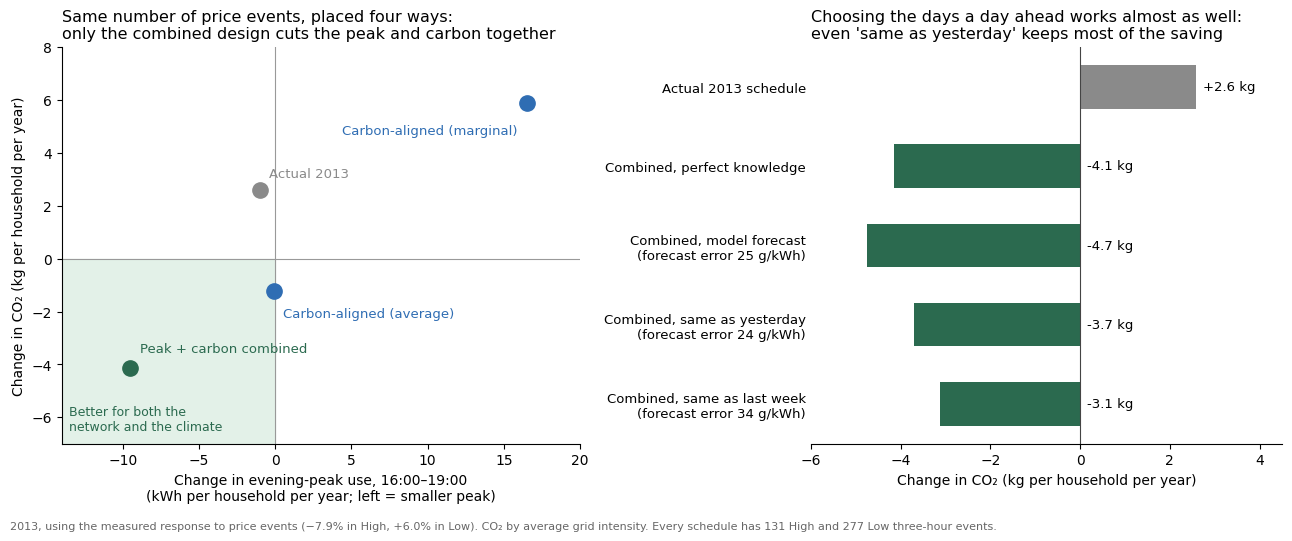

In [9]:
#@title Figure: a tariff for the peak and carbon together

import matplotlib
import matplotlib.pyplot as plt

def make_figure_05(sched, fc, path):
    """sched: list of (name, peak_kwh, kg_avg); fc: list of (name, kg_avg, mae or None)."""
    blue, red, green, grey = "#2f6db3", "#c0392b", "#2b6a4f", "#8a8a8a"
    fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.1, 1]})

    a.axhline(0, color="#999", lw=0.8); a.axvline(0, color="#999", lw=0.8)
    a.fill_between([-14, 0], -7, 0, color="#e3f1e8", zorder=0)
    a.text(-13.5, -6.6, "Better for both the\nnetwork and the climate", fontsize=9, color=green, va="bottom")
    colors = {"Actual 2013": grey, "Peak + carbon combined": green}
    offsets = {"Actual 2013": (0.6, 0.5), "Carbon-aligned (average)": (0.6, -1.0),
               "Carbon-aligned (marginal)": (-0.6, -1.2), "Peak + carbon combined": (0.6, 0.6)}
    for name, x, y in sched:
        c = colors.get(name, blue)
        a.plot(x, y, "o", ms=11, color=c, zorder=3)
        dx, dy = offsets.get(name, (0.6, 0.4))
        a.text(x + dx, y + dy, name, fontsize=9.5, color=c, ha="left" if dx > 0 else "right")
    a.set_xlim(-14, 20); a.set_ylim(-7, 8)
    a.set_xlabel("Change in evening-peak use, 16:00–19:00\n(kWh per household per year; left = smaller peak)")
    a.set_ylabel("Change in CO₂ (kg per household per year)")
    a.set_title("Same number of price events, placed four ways:\nonly the combined design cuts the peak and carbon together",
                loc="left", fontsize=11.5)

    names = [f[0] + (f"\n(forecast error {f[2]:.0f} g/kWh)" if f[2] else "") for f in fc]; vals = [f[1] for f in fc]
    ys = list(range(len(fc)))[::-1]
    cols = [grey] + [green] * (len(fc) - 1)
    b.barh(ys, vals, color=cols, height=0.55)
    b.axvline(0, color="#444", lw=0.8)
    for y, (n, v, mae) in zip(ys, fc):
        b.text(max(v, 0) + 0.15, y, f"{v:+.1f} kg", va="center", ha="left", fontsize=9.5)
    b.set_yticks(ys, names, fontsize=9.5)
    b.set_xlim(-6, 4.5)
    b.set_xlabel("Change in CO₂ (kg per household per year)")
    b.set_title("Choosing the days a day ahead works almost as well:\neven 'same as yesterday' keeps most of the saving",
                loc="left", fontsize=11.5)
    for ax in (a, b):
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    b.spines["left"].set_visible(False); b.tick_params(axis="y", length=0)
    fig.text(0.01, 0.01, "2013, using the measured response to price events (−7.9% in High, +6.0% in Low). "
             "CO₂ by average grid intensity. Every schedule has 131 High and 277 Low three-hour events.",
             fontsize=8, color="#666")
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(path, dpi=160)
    return fig


sched = [(r["schedule"], r["evening-peak kWh change per household"], r["kg CO2 per household (average)"])
         for _, r in results.iterrows()]
mae = {"Combined, model forecast": mean_absolute_error(test["ci"], test["fc_model"]),
       "Combined, yesterday's values": mean_absolute_error(test["ci"], test["lag_1d"]),
       "Combined, last week's values": mean_absolute_error(test["ci"], test["lag_7d"])}
labels = {"Actual 2013": "Actual 2013 schedule", "Combined, perfect knowledge": "Combined, perfect knowledge",
          "Combined, model forecast": "Combined, model forecast",
          "Combined, yesterday's values": "Combined, same as yesterday",
          "Combined, last week's values": "Combined, same as last week"}
fc = [(labels[k], fc_results.loc[k, "kg CO2 per household (average)"], mae.get(k)) for k in options]

!mkdir -p figures
make_figure_05(sched, fc, "figures/peak_carbon_tariff.png")
plt.show()

## What this means

- **How events are timed decides whether a tariff helps or harms the climate.** The trial's response was real (about 8% less use in High events, 6% more in Low periods), but its timing added a little CO₂.
- **One tariff can serve the network and the climate together**, if High events stay in the evening and the *days* are chosen by grid carbon. With the trial's own response, that cuts the evening peak about ten times more than the actual schedule and saves roughly 6.7 kg CO₂ per household a year, around 22,000 tonnes if every London home were on it.
- **It doesn't need a sophisticated forecast.** Ranking days by yesterday's carbon intensity captures about 94% of the benefit. The machine-learning model was no more accurate than that simple rule, which is itself a useful result: the simplest workable method was enough.
- **The lever is small.** Event pricing moves a fraction of a percent of a household's emissions. Larger effects would need more events, stronger price differences, or automated response.

**Limits.** The response is assumed to be the same percentage whenever an event falls; it comes from one trial, with volunteers. Marginal intensity is by hour of day only. The placebo rests on fewer households in early 2012. The forecast model uses actual London weather in place of a weather forecast.

**Next:** notebook 06 looks at who responds: grouping households by the shape of their daily electricity use.